# Plots (ALMA Subtype v2)

## Load data

In [1]:
import pandas as pd
import sys
sys.path.append('../')
from utils.plots import *
output_notebook()

model_name1 = 'ALMA Subtype v2'
model_name2 = 'AML Epigenomic Risk'
model_name3 = '38CpG-AMLsignature'


clinical_data = '/mnt/f/ALMA/Intermediate_Files/clinical_data.xlsx'
prediction_data_train = '../../alma-transformer/results/3314samples_331556cpgs_withbatchcorrection_bvalues_predictions.csv'
prediction_data_test = '../../alma-transformer/results/201samples_331556cpgs_nobatchcorrection_bvalues_predictions.csv'

# Create df by first concat prediction data train and test, then join with clinical data
df1 = pd.read_csv(prediction_data_train, index_col=0).sort_index()
df2 = pd.read_csv(prediction_data_test, index_col=0).sort_index()
df = pd.concat([df1, df2], axis=0).sort_index()
df = df.join(pd.read_excel(clinical_data, index_col=0)).sort_index()

# Read ONT hematopathology test cohort
nanopore = pd.read_csv('/mnt/f/ALMA/Intermediate_Files/nanoporeseq_epigenomic_predictions_clinicaldata_FM_v5_11-27-2025.csv', index_col=0)

# Concat with df
df2 = pd.concat([df, nanopore], axis=0).sort_index()

# Define train and test samples
df_train = df2[df2['Train-Test']=='Train Sample']
df_test = df2[df2['Train-Test'] == 'Test Sample']

# remove duplicates from the test cohort
df_test = df_test[~df_test['Patient_ID'].duplicated(keep='last')]

# Prognostic model samples
df_px = df[~df['Vital Status at 5y'].isna()]
df_px2 = df_px[df_px['Clinical Trial'].isin(['AAML0531', 'AAML1031', 'AAML03P1'])]
df_px2 = df_px2[df_px2['Sample Type'].isin(
    ['Diagnosis', 'Primary Blood Derived Cancer - Bone Marrow', 'Primary Blood Derived Cancer - Peripheral Blood'])]
df_px2 = df_px2[~df_px2['Patient_ID'].duplicated(keep='last')]

# drop the samples with missing labels for the ELN AML 2022 Diagnosis
df_dx = df_train[~df_train['WHO 2022 Diagnosis'].isna()]

# exclude the classes with fewer than 5 samples
df_dx = df_dx[~df_dx['WHO 2022 Diagnosis'].isin(['AML with t(9;22); BCR::ABL1'])]


Loading BokehJS ...

## Patient Characteristics

### ALMA (unsupervised)

In [2]:
from tableone import TableOne
from datetime import date

columns = ['Hematopoietic Entity','Age (group years)','Sex',
            'Clinical Trial',]

mytable_cog = TableOne(df_train.reset_index(), columns,
                        overall=False, missing=False,
                        pval=False, pval_adjust=False,
                        htest_name=True,dip_test=True,
                        tukey_test=True, normal_test=True,

                        order={'FLT3 ITD':['Yes','No'],
                                'Age (group years)':['0-5','5-13','13-39','39-60'],
                                'MRD 1 Status': ['Positive'],
                                'Risk Group': ['High Risk', 'Standard Risk'],
                                'FLT3 ITD': ['Yes'],
                                'Leucocyte counts (10⁹/L)': ['≥30'],
                                'Age group (years)': ['≥10']})

# mytable_cog.to_excel('../data/pt_characteristics_alma_model_' + str(date.today()) +'.xlsx')

mytable_cog.tabulate(tablefmt="html", 
                        # headers=[score_name,"",'Missing','Discovery','Validation','p-value','Statistical Test']
                        )

,,Overall
n,,3314
"Hematopoietic Entity, n (%)",Acute lymphoblastic leukemia (ALL),700 (28.3)
,Acute myeloid leukemia (AML),1221 (49.4)
,Acute promyelocytic leukemia (APL),31 (1.3)
,Mixed phenotype acute leukemia (MPAL),48 (1.9)
,Myelodysplastic syndrome (MDS or MDS-like),223 (9.0)
,Otherwise-Normal (Control),251 (10.1)
"Age (group years), n (%)",0-5,480 (24.1)
,5-13,483 (24.2)
,13-39,663 (33.2)


### Fine-tuned (supervised) Dx and Px models

In [3]:
columns = ['Age (years)','Age group (years)','Sex','Race or ethnic group',
            'Hispanic or Latino ethnic group', 'MRD 1 Status',
            'Leucocyte counts (10⁹/L)', 'BM leukemic blasts (%)',
            'Risk Group','FLT3 ITD', 'Clinical Trial']

df_test['Age (years)'] = df_test['Age (years)'].astype(float)


all_cohorts = pd.concat([df_dx, df_px2],
                         axis=0, keys=[model_name1,model_name2 + ', ' + model_name3],
                         names=['cohort']).reset_index()

mytable_cog = TableOne(all_cohorts, columns,
                        overall=False, missing=False,
                        pval=False, pval_adjust=False,
                        htest_name=True,dip_test=True,
                        tukey_test=True, normal_test=True,

                        order={'FLT3 ITD':['Yes','No'],
                                'Race or ethnic group':['White','Black or African American','Asian'],
                                'MRD 1 Status': ['Positive'],
                                'Risk Group': ['High Risk', 'Standard Risk'],
                                'FLT3 ITD': ['Yes'],
                                'Leucocyte counts (10⁹/L)': ['≥30'],
                                'Age group (years)': ['≥10']},
                                groupby='cohort')

# mytable_cog.to_excel('../data/pt_characteristics_fine-tuned_models_' + str(date.today()) +'.xlsx')

mytable_cog.tabulate(tablefmt="html", 
                        # headers=[score_name,"",score_name,'Validation','p-value','Statistical Test']
)

,,ALMA Subtype v2,"AML Epigenomic Risk, 38CpG-AMLsignature"
n,,2471,946
"Age (years), mean (SD)",,19.2 (19.7),9.4 (6.3)
"Age group (years), n (%)",≥10,528 (47.4),463 (48.9)
,<10,586 (52.6),483 (51.1)
"Sex, n (%)",Female,711 (50.5),468 (49.5)
,Male,697 (49.5),478 (50.5)
"Race or ethnic group, n (%)",White,1064 (80.5),697 (79.1)
,Black or African American,131 (9.9),102 (11.6)
,Asian,65 (4.9),43 (4.9)
,American Indian or Alaska Native,7 (0.5),5 (0.6)


## Sankey plots

```{note}
Sankey plots below compare the distribution of categories. The width of the lines is proportional to the number of patients in each group.
```

### Samples with annotated diagnosis info

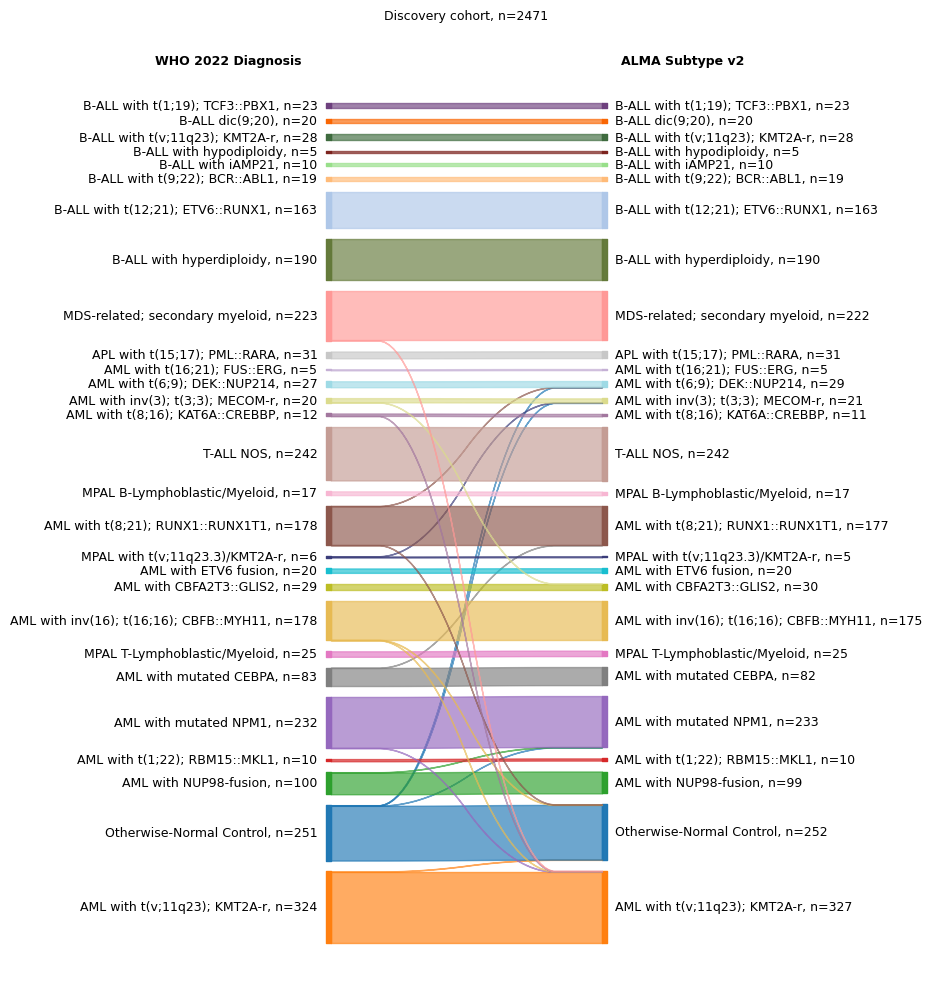

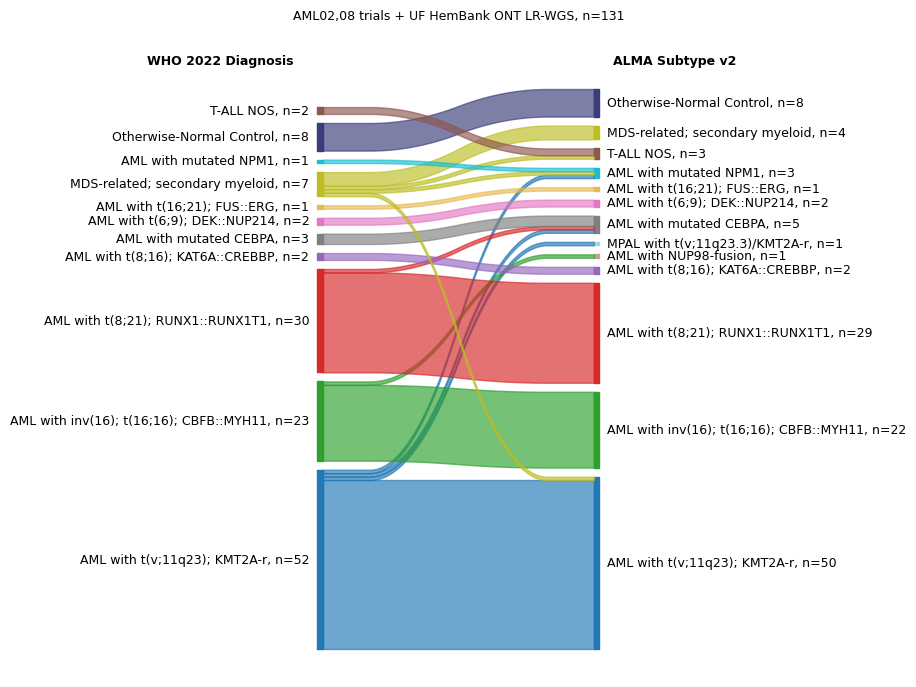

In [30]:
colors = get_custom_color_palette()


draw_sankey_plot(df_dx, 'WHO 2022 Diagnosis', model_name1, colors,
                 title='Discovery cohort', fig_size=(4, 12),
                 fontsize=9, nan_action='drop1')

draw_sankey_plot(df_test, 'WHO 2022 Diagnosis', model_name1, colors,
                 title= 'AML02,08 trials + UF HemBank ONT LR-WGS',fig_size=(4, 8),
                 fontsize=9, nan_action='drop1')

### Predictions in samples for which no WHO 22 Dx data was available

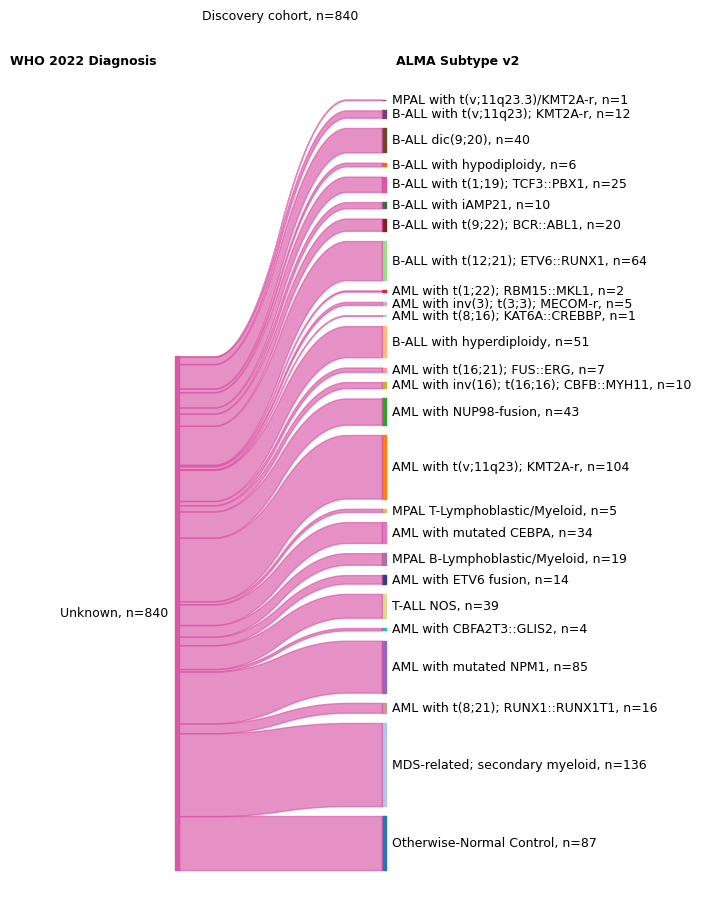

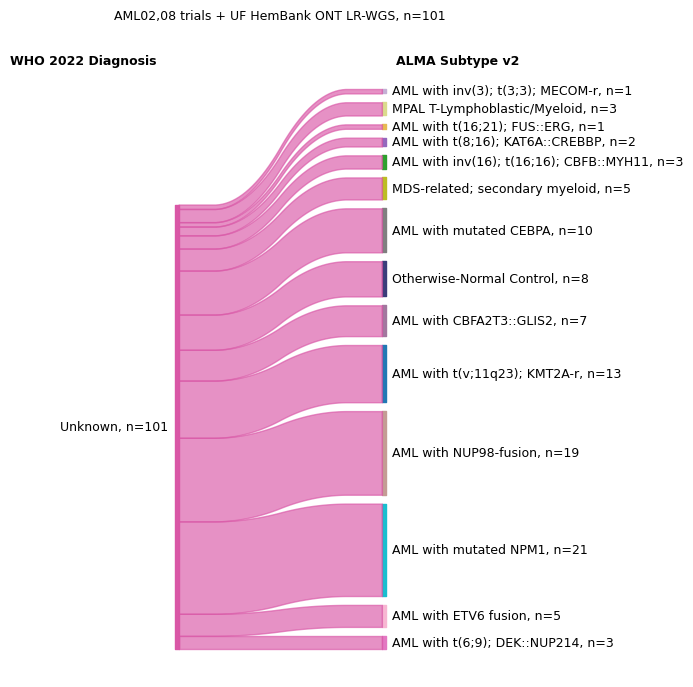

In [31]:
draw_sankey_plot(df_train, 'WHO 2022 Diagnosis', model_name1, colors,
                 title='Discovery cohort', fig_size=(3, 11),
                 fontsize=9, nan_action='keep-only')

draw_sankey_plot(df_test, 'WHO 2022 Diagnosis', model_name1, colors,
                 title= 'AML02,08 trials + UF HemBank ONT LR-WGS',fig_size=(3, 8),
                 fontsize=9, nan_action='keep-only')

## Performance metrics

### Diagnosis

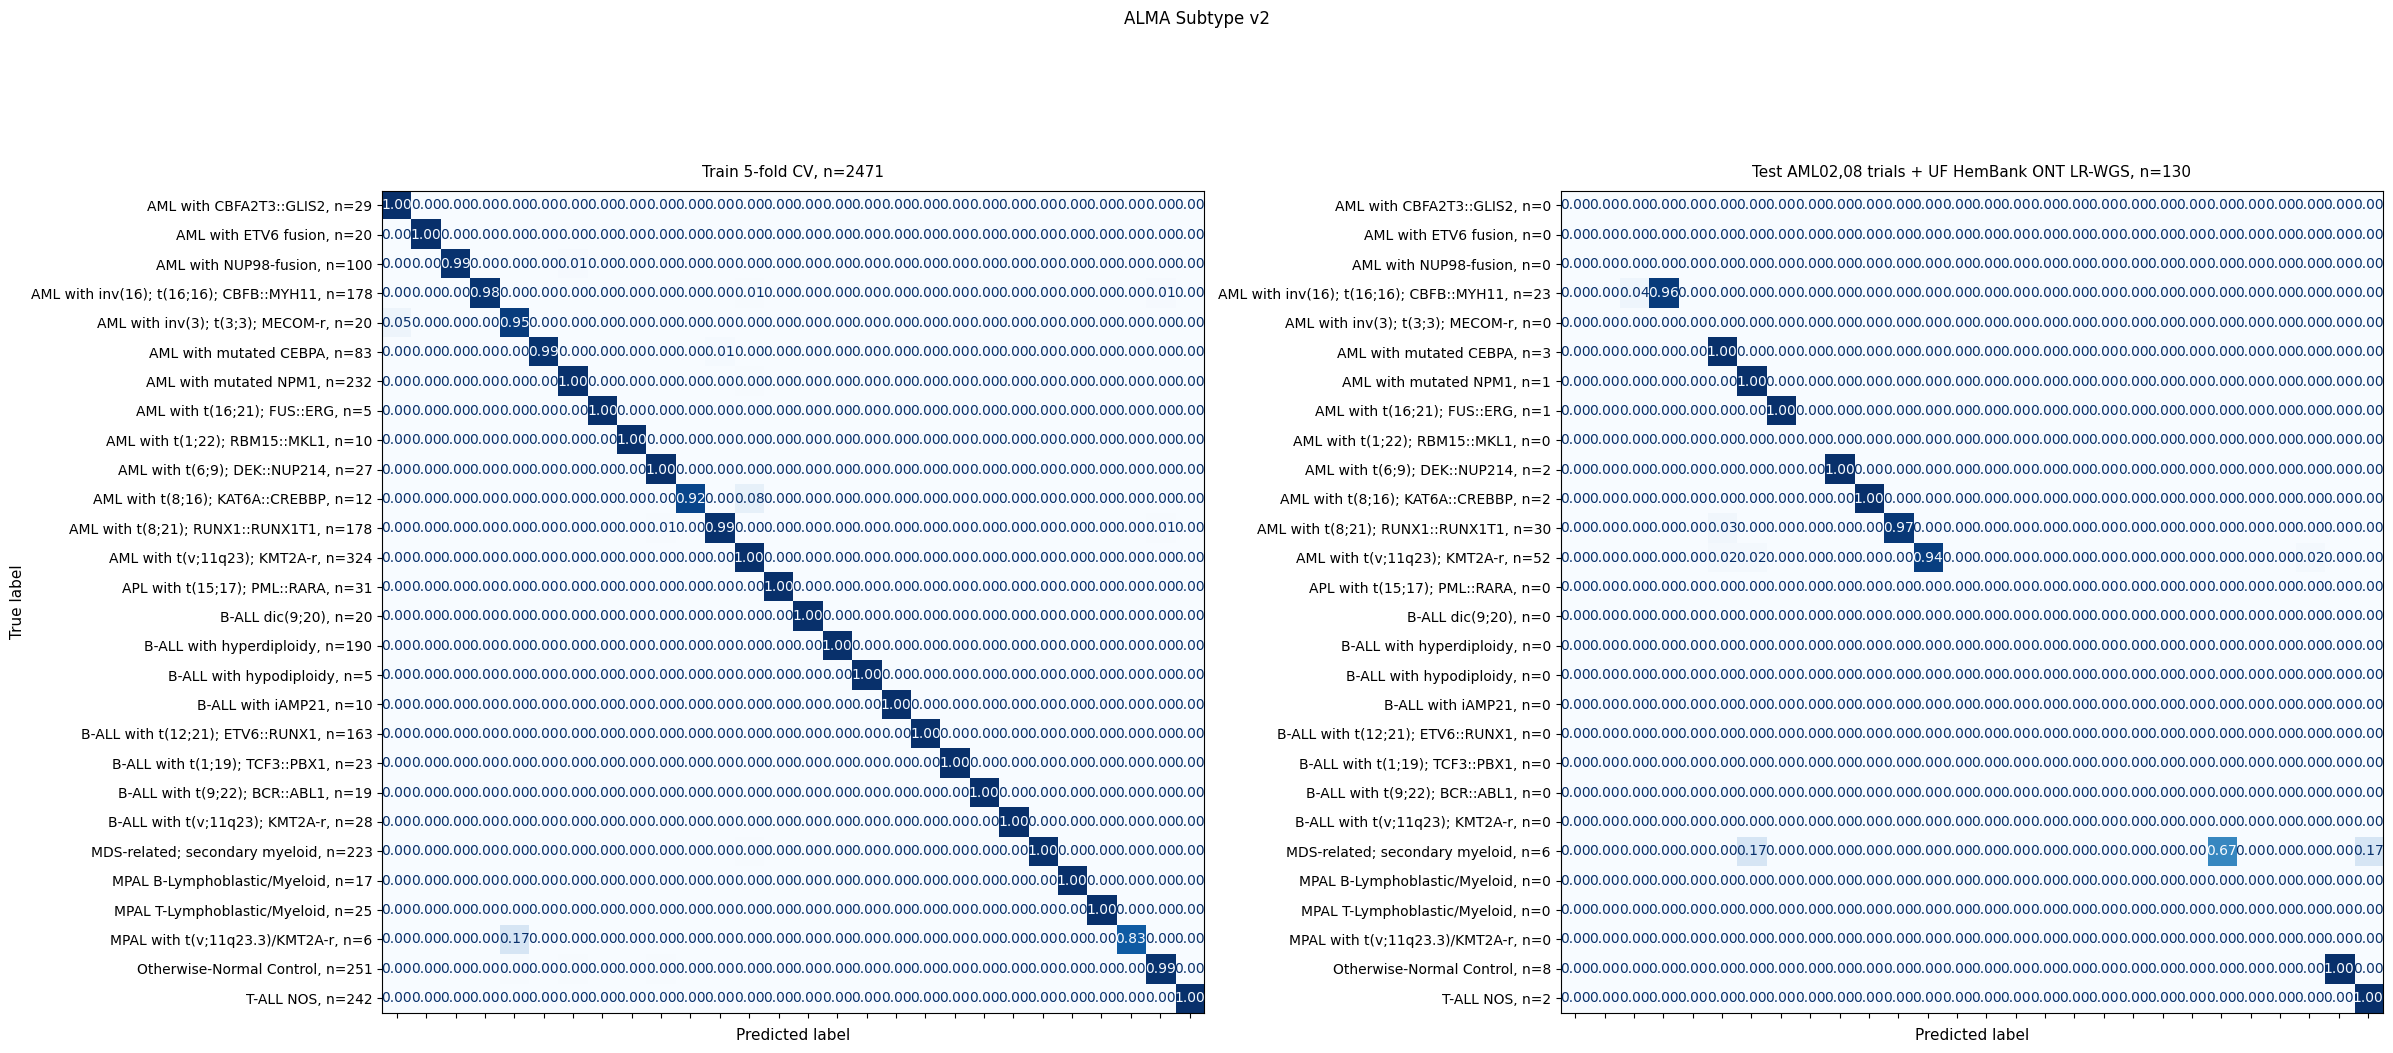


Metrics:
|                                              |   Accuracy |   Weighted F1 |   Cohen's Kappa |   Micro Sensitivity |   Micro Specificity |
|:---------------------------------------------|-----------:|--------------:|----------------:|--------------------:|--------------------:|
| Train 5-fold CV                              |      0.994 |         0.994 |           0.993 |               0.994 |               1     |
| Test AML02,08 trials + UF HemBank ONT LR-WGS |      0.946 |         0.958 |           0.929 |               0.946 |               0.996 |


In [36]:
# Drop nans from df_test['WHO 2022 Diagnosis']
df_test2 = df_test.dropna(subset=['WHO 2022 Diagnosis'])

df_dict = {
    'Train 5-fold CV': df_dx.fillna('Not confident'),
    'Test AML02,08 trials + UF HemBank ONT LR-WGS': df_test2.fillna('Not confident'),
}

plot_confusion_matrix_stacked(
    df_dict=df_dict,
    true_col='WHO 2022 Diagnosis',
    pred_col=model_name1,
    class_col='WHO 2022 Diagnosis',  
    title=str(model_name1),
    figsize_per_plot=(12, 12),
    
)

## Watermark

In [4]:
%load_ext watermark

In [5]:
# watermark with all libraries used in this notebook
%watermark -v -p pandas,seaborn,matplotlib,tableone,sklearn,lifelines,scipy -a Francisco_Marchi@Lamba_Lab_UF -d -m -r -u

Author: Francisco_Marchi@Lamba_Lab_UF

Last updated: 2025-11-28

Python implementation: CPython
Python version       : 3.10.13
IPython version      : 8.27.0

pandas    : 2.2.2
seaborn   : 0.13.2
matplotlib: 3.9.2
tableone  : 0.8.0
sklearn   : 1.5.2
lifelines : 0.28.0
scipy     : 1.12.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.87.1-microsoft-standard-WSL2
Machine     : x86_64
Processor   : x86_64
CPU cores   : 32
Architecture: 64bit

Git repo: git@github.com:f-marchi/ALMA.git

